# End-to-End Sales Forecasting & Demand Intelligence System

### Internship: XYlofy AI

Author: Chirag Nagra

Week 3 & Week 4 Project

In [1]:
# ==========================================
# Sales Forecasting & Demand Intelligence
# XYlofy AI Internship
# Author: Chirag Nagra
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
# Load Dataset

df = pd.read_csv("../data/train.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [3]:
# Shape of Dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows : 9800
Columns : 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Postal Code    11
dtype: int64

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [9]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [11]:
df['Order Date'].head(10)

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: Order Date, dtype: str

In [12]:
df['Ship Date'].head(10)

0    11/11/2017
1    11/11/2017
2    16/06/2017
3    18/10/2016
4    18/10/2016
5    14/06/2015
6    14/06/2015
7    14/06/2015
8    14/06/2015
9    14/06/2015
Name: Ship Date, dtype: str

In [13]:
# Convert Date Columns

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d/%m/%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d/%m/%Y'
)

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [14]:
# ==========================================
# Feature Engineering
# ==========================================

# Year
df['Year'] = df['Order Date'].dt.year

# Month Number
df['Month'] = df['Order Date'].dt.month

# Month Name
df['Month Name'] = df['Order Date'].dt.month_name()

# Quarter
df['Quarter'] = df['Order Date'].dt.quarter

# Week Number
df['Week'] = df['Order Date'].dt.isocalendar().week.astype(int)

# Day
df['Day'] = df['Order Date'].dt.day

# Day Name
df['Day Name'] = df['Order Date'].dt.day_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Quarter,Week,Day,Day Name
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,45,8,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,45,8,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,24,12,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,41,11,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,41,11,Tuesday


In [15]:
# ==========================================
# Season Feature
# ==========================================

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df[["Month", "Season"]].head()

,Month,Season
0,11,Autumn
1,11,Autumn
2,6,Monsoon
3,10,Autumn
4,10,Autumn


In [16]:
# ==========================================
# Shipping Days
# ==========================================

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [17]:
# Save Processed Dataset

df.to_csv("../data/processed_sales.csv", index=False)

print("Processed Dataset Saved Successfully ✅")

Processed Dataset Saved Successfully ✅


In [18]:
# ==========================================
# Total Revenue by Category
# ==========================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

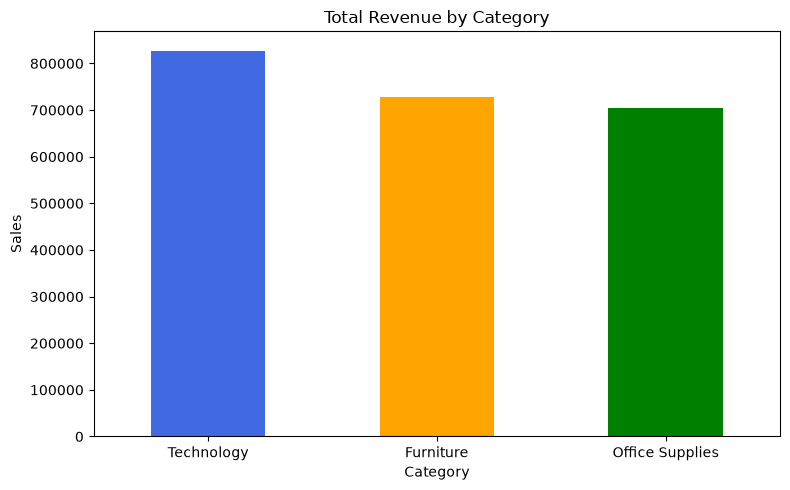

In [19]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color=["royalblue","orange","green"]
)

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../charts/category_sales.png")

plt.show()

In [20]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

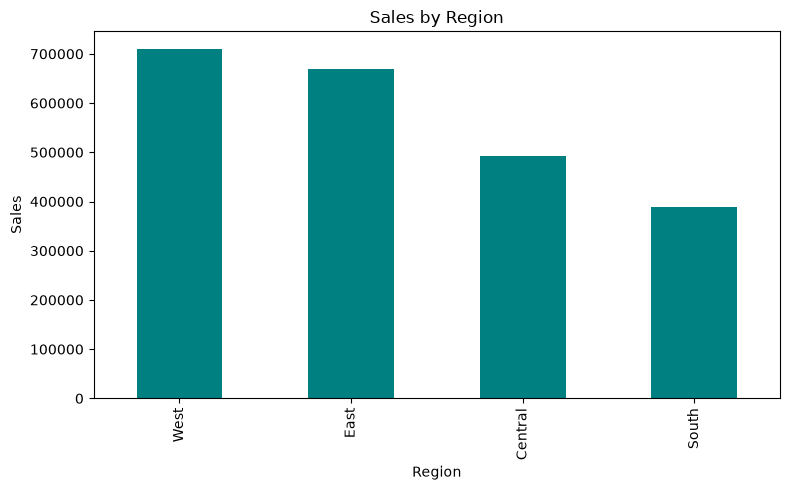

In [21]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind="bar",
    color="teal"
)

plt.title("Sales by Region")

plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("../charts/region_sales.png")

plt.show()

In [22]:
shipping = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

display(shipping)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

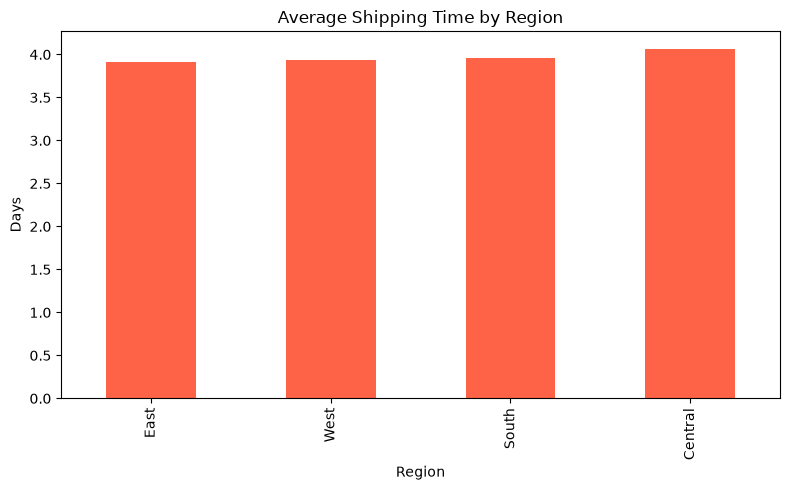

In [23]:
plt.figure(figsize=(8,5))

shipping.plot(
    kind="bar",
    color="tomato"
)

plt.title("Average Shipping Time by Region")

plt.ylabel("Days")

plt.tight_layout()

plt.savefig("../charts/shipping_days.png")

plt.show()

In [24]:
monthly_sales = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


In [25]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

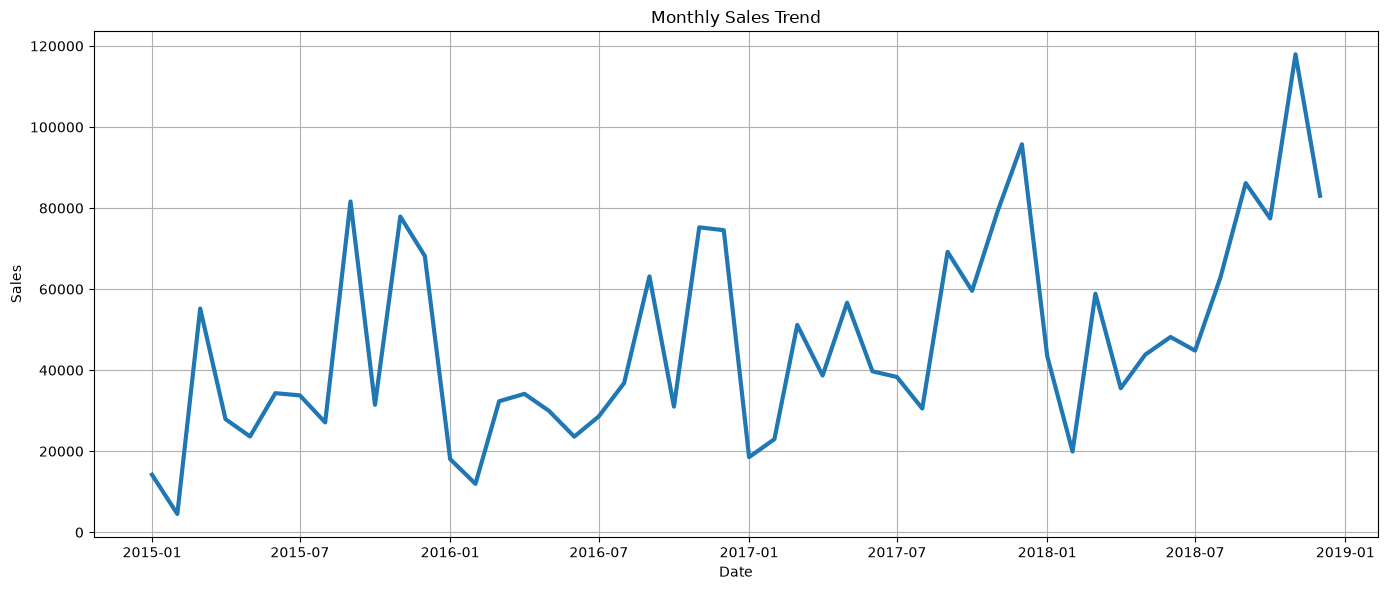

In [26]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    linewidth=3
)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("../charts/monthly_sales.png")

plt.show()

In [27]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

display(segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

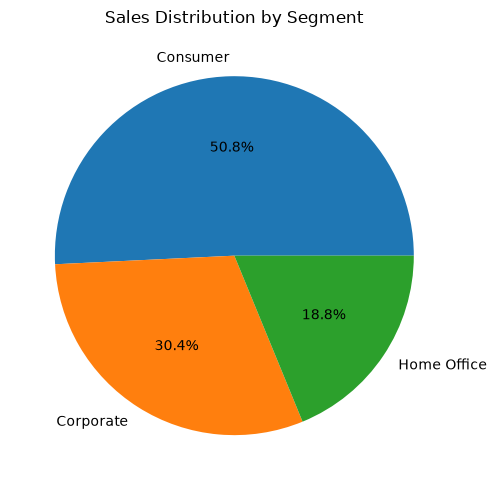

In [28]:
plt.figure(figsize=(8,5))

segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Sales Distribution by Segment")

plt.tight_layout()

plt.savefig("../charts/segment_sales.png")

plt.show()

# Task 2 - Time Series Analysis & Decomposition

In [39]:
# ==========================================
# Task 2 - Import Libraries
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
import pandas as pd

In [40]:
# ==========================================
# Monthly Sales Time Series
# ==========================================

monthly_ts = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"      # Latest Pandas uses ME instead of M
        )
    )["Sales"]
    .sum()
)

print(monthly_ts.head())

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


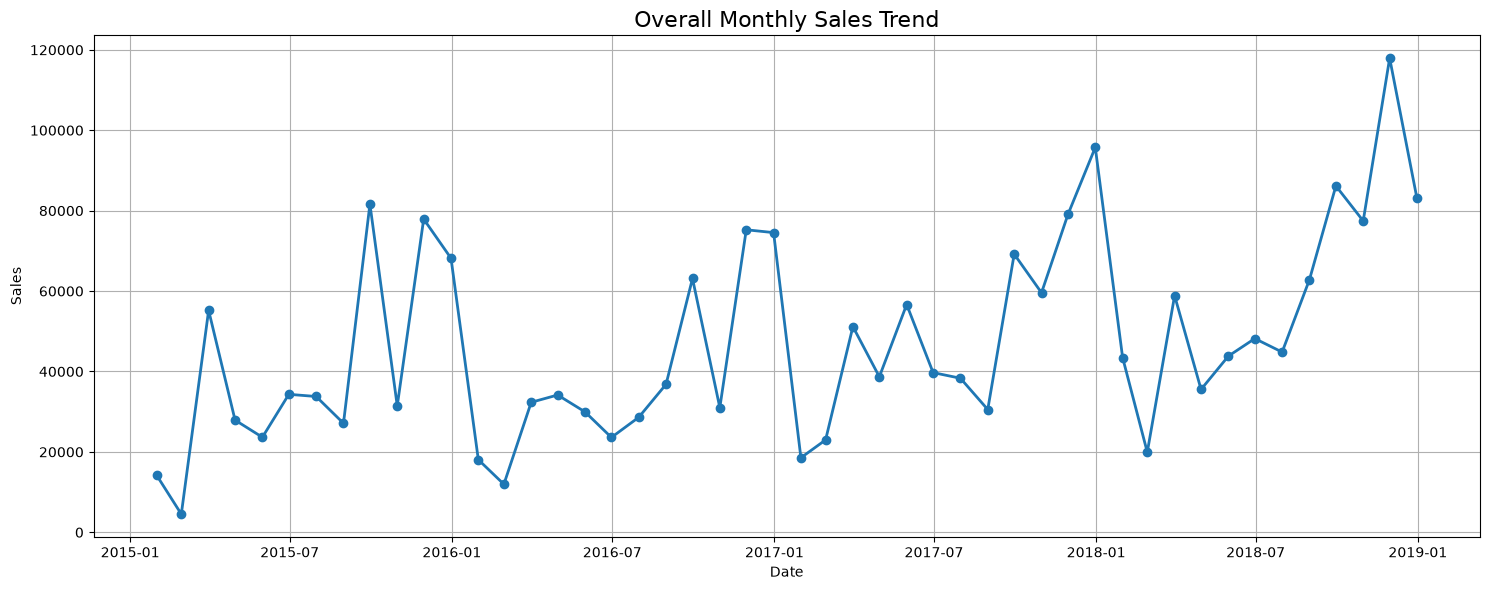

In [41]:
# ==========================================
# Overall Monthly Sales Trend
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts.index,
    monthly_ts.values,
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("../charts/monthly_sales_trend.png")

plt.show()

In [42]:
# ==========================================
# Time Series Decomposition
# ==========================================

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

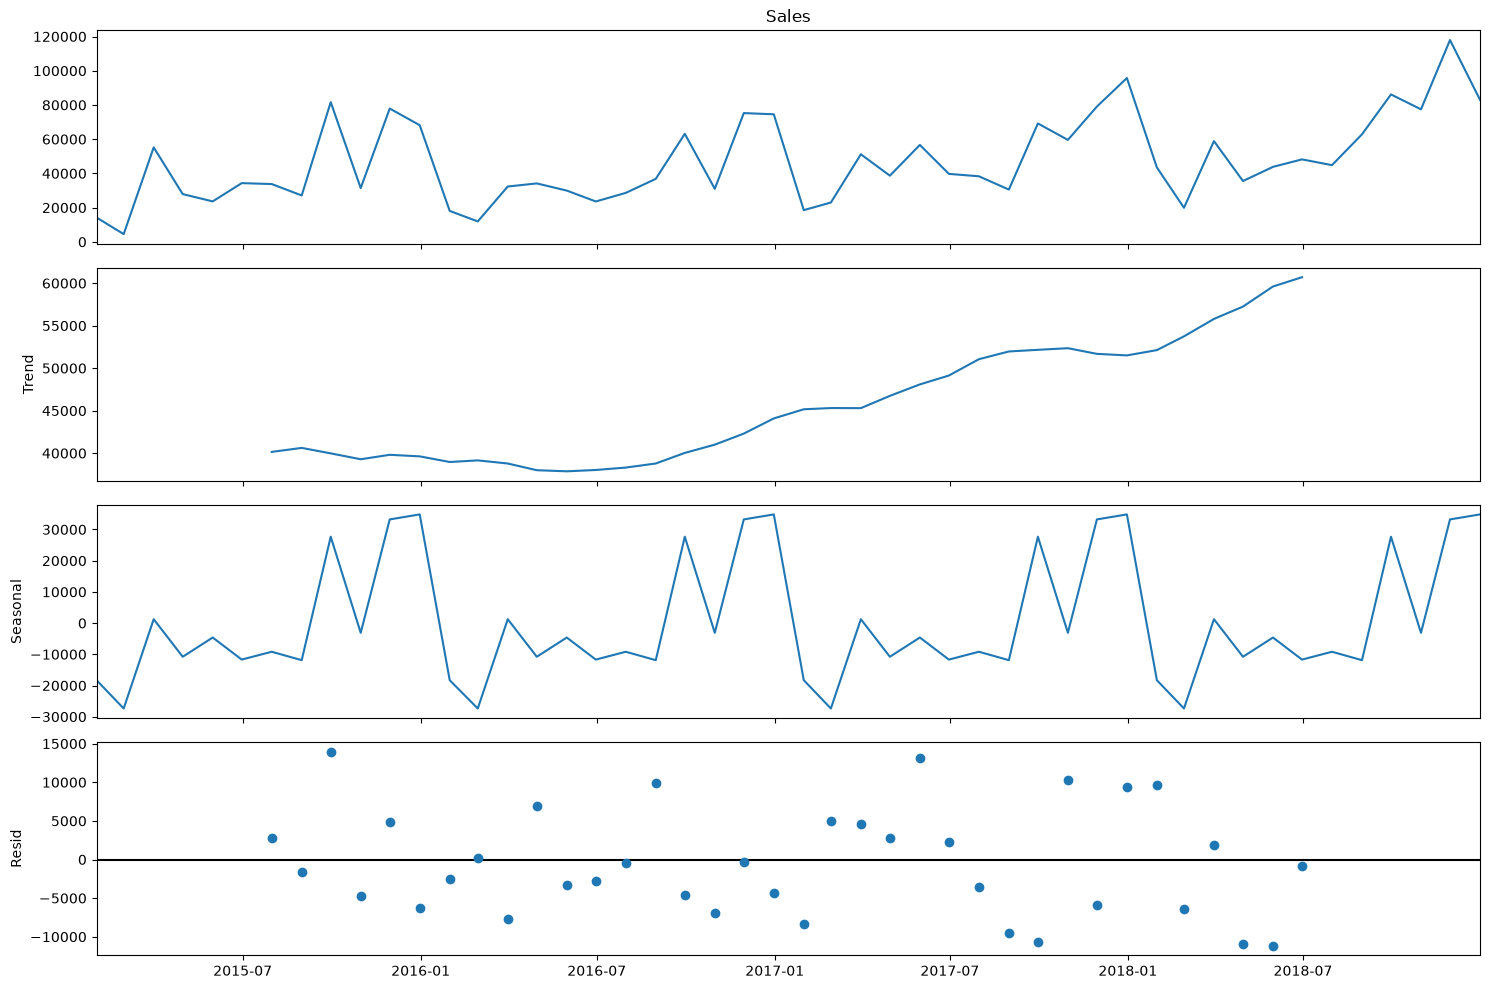

In [43]:
# ==========================================
# Plot Decomposition
# ==========================================

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.savefig("../charts/time_series_decomposition.png")

plt.show()

In [44]:
# ==========================================
# Augmented Dickey Fuller Test
# ==========================================

result = adfuller(monthly_ts)

print("ADF Statistic :", result[0])

print("P-Value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
P-Value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [45]:
# ==========================================
# Stationarity Check
# ==========================================

if result[1] < 0.05:
    print("✅ Time Series is Stationary")
else:
    print("❌ Time Series is NOT Stationary")

✅ Time Series is Stationary


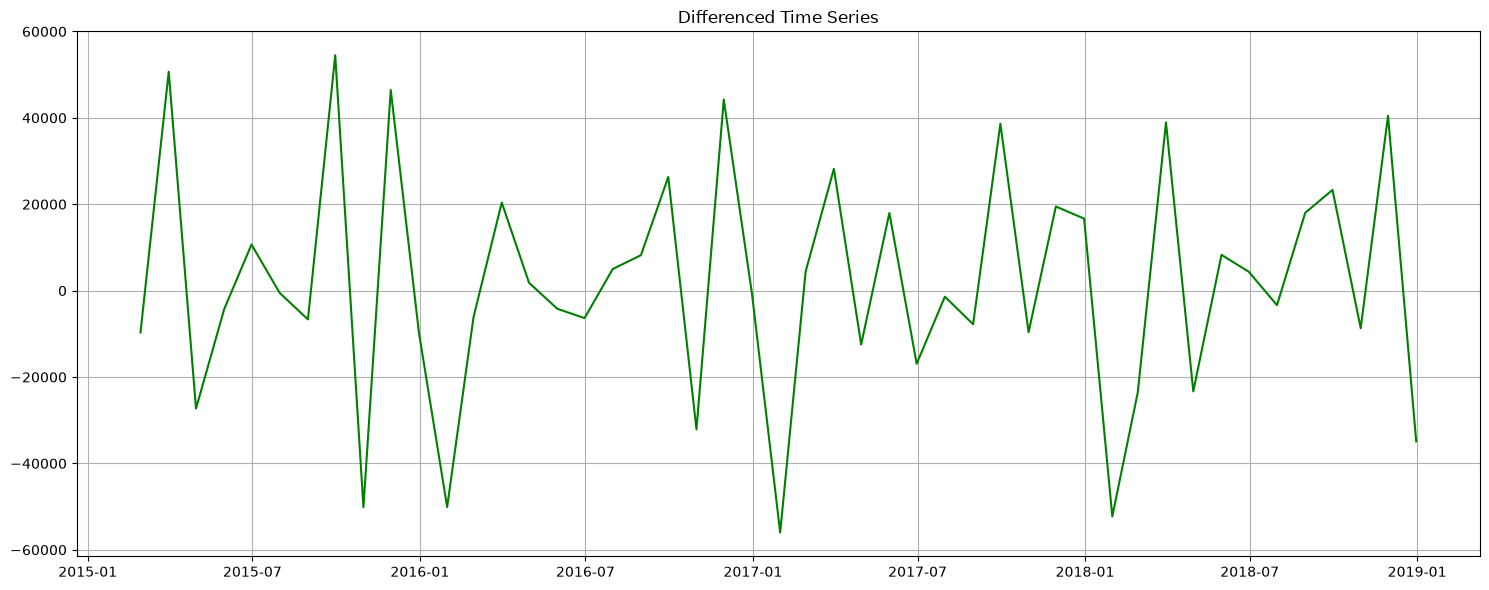

In [46]:
# ==========================================
# First Order Differencing
# ==========================================

monthly_diff = monthly_ts.diff().dropna()

plt.figure(figsize=(15,6))

plt.plot(
    monthly_diff,
    color="green"
)

plt.title("Differenced Time Series")

plt.grid(True)

plt.tight_layout()

plt.savefig("../charts/differenced_series.png")

plt.show()

In [47]:
# ==========================================
# ADF After Differencing
# ==========================================

result2 = adfuller(monthly_diff)

print("ADF Statistic :", result2[0])

print("P-Value :", result2[1])

if result2[1] < 0.05:
    print("✅ Series became Stationary")
else:
    print("❌ Still Non Stationary")

ADF Statistic : -8.727061830353277
P-Value : 3.266917547279475e-14
✅ Series became Stationary


## Observations

### Trend
- Monthly sales show an overall increasing trend.

### Seasonality
- Seasonal fluctuations are visible across different months.

### Residual
- Random variations exist which are not explained by trend or seasonality.

### Stationarity
- ADF Test was used to determine whether the time series is stationary.
- After first-order differencing, the series became suitable for forecasting models if required.

# Task 3 - Sales Forecasting using 3 Different Models

## Model 1 - SARIMA

In [55]:
# ==========================================
# Import Libraries for SARIMA
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [56]:
# ==========================================
# Train Test Split
# ==========================================

train = monthly_ts.iloc[:-3]

test = monthly_ts.iloc[-3:]

print("Train Samples :", len(train))
print("Test Samples :", len(test))

print("\nTrain")
display(train)

print("\nTest")
display(test)

Train Samples : 45
Test Samples : 3

Train


Order Date
2015-01-31    14205.7070
2015-02-28     4519.8920
2015-03-31    55205.7970
2015-04-30    27906.8550
2015-05-31    23644.3030
2015-06-30    34322.9356
2015-07-31    33781.5430
2015-08-31    27117.5365
2015-09-30    81623.5268
2015-10-31    31453.3930
2015-11-30    77907.6607
2015-12-31    68167.0585
2016-01-31    18066.9576
2016-02-29    11951.4110
2016-03-31    32339.3184
2016-04-30    34154.4685
2016-05-31    29959.5305
2016-06-30    23599.3740
2016-07-31    28608.2590
2016-08-31    36818.3422
2016-09-30    63133.6060
2016-10-31    31011.7375
2016-11-30    75249.3995
2016-12-31    74543.6012
2017-01-31    18542.4910
2017-02-28    22978.8150
2017-03-31    51165.0590
2017-04-30    38679.7670
2017-05-31    56656.9080
2017-06-30    39724.4860
2017-07-31    38320.7830
2017-08-31    30542.2003
2017-09-30    69193.3909
2017-10-31    59583.0330
2017-11-30    79066.4958
2017-12-31    95739.1210
2018-01-31    43476.4740
2018-02-28    19920.9974
2018-03-31    58863.4128
2018-04-30    


Test


Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

In [57]:
# ==========================================
# Build SARIMA Model
# ==========================================

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print("SARIMA Model Trained Successfully ✅")

SARIMA Model Trained Successfully ✅


In [58]:
# ==========================================
# Forecast Next 3 Months
# ==========================================

sarima_forecast = sarima_result.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

print("Forecast Generated Successfully ✅")

forecast_values

Forecast Generated Successfully ✅


2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64

In [59]:
# ==========================================
# Model Evaluation
# ==========================================

mae = mean_absolute_error(test, forecast_values)

rmse = np.sqrt(
    mean_squared_error(test, forecast_values)
)

mape = np.mean(
    np.abs((test - forecast_values) / test)
) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53%


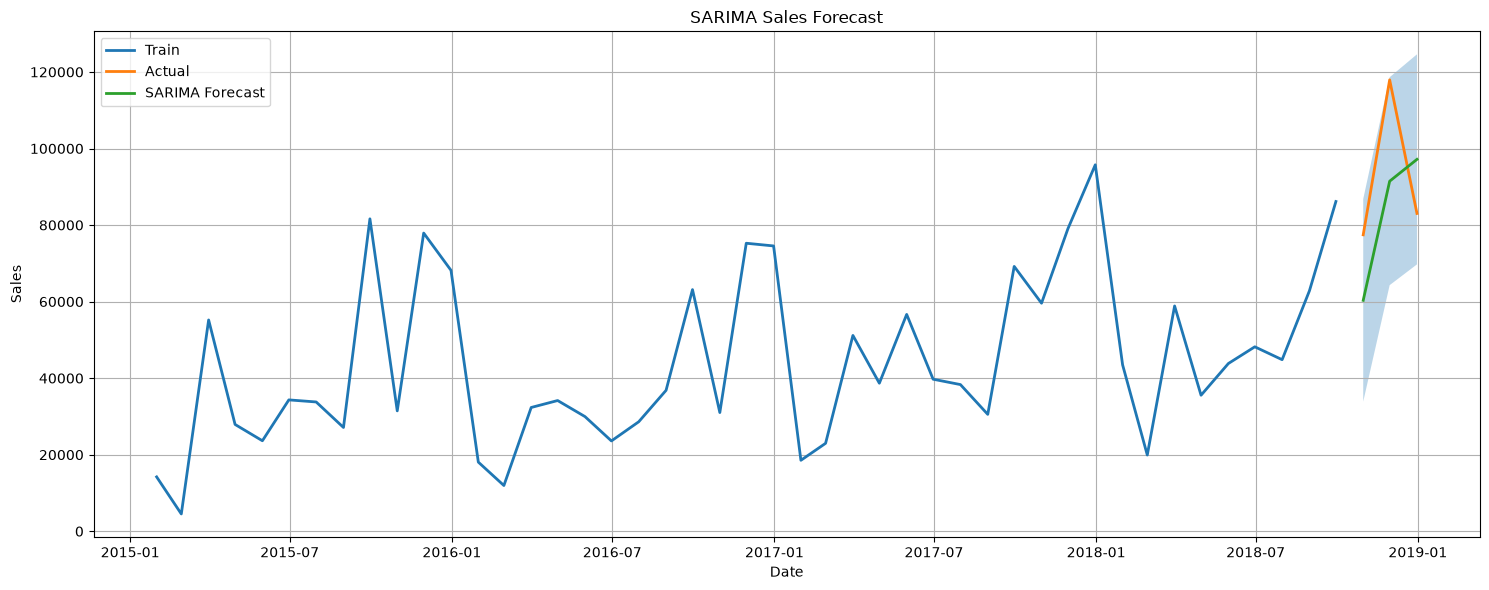

In [60]:
# ==========================================
# Plot SARIMA Forecast
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(train.index, train, label="Train", linewidth=2)

plt.plot(test.index, test, label="Actual", linewidth=2)

plt.plot(forecast_values.index, forecast_values, label="SARIMA Forecast", linewidth=2)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:, 0],
    confidence_interval.iloc[:, 1],
    alpha=0.3
)

plt.title("SARIMA Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../charts/sarima_forecast.png")

plt.show()

In [61]:
# ==========================================
# Forecast Comparison Table
# ==========================================

sarima_results = pd.DataFrame({
    "Actual Sales": test.values,
    "Forecast Sales": forecast_values.values
})

display(sarima_results)

,Actual Sales,Forecast Sales
0,77448.1312,60331.792073
1,117938.1550,91458.220227
2,83030.3888,97167.570936


## Model 2 - Prophet Forecasting

In [62]:
# ==========================================
# Prepare Data for Prophet
# ==========================================

prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

display(prophet_df.head())

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [63]:
# ==========================================
# Train Test Split
# ==========================================

train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

print("Train :", len(train_prophet))
print("Test :", len(test_prophet))

Train : 45
Test : 3


In [64]:
# ==========================================
# Train Prophet Model
# ==========================================

from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

print("Prophet Model Trained Successfully ✅")

13:49:47 - cmdstanpy - INFO - Chain [1] start processing
13:49:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Trained Successfully ✅


In [65]:
# ==========================================
# Forecast using Prophet
# ==========================================

future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39925.670897,56023.862982,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78696.495427,95039.152534,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,42989.768534,58903.089583,55957.446182,55957.739461,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82269.656551,98477.361972,56456.474572,56457.403470,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81347.157668,98416.829928,56971.972800,56973.888887,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [66]:
# ==========================================
# Extract Forecast
# ==========================================

forecast_values_prophet = forecast["yhat"].tail(3).values

actual_values = test_prophet["y"].values

comparison = pd.DataFrame({
    "Actual": actual_values,
    "Forecast": forecast_values_prophet
})

display(comparison)

,Actual,Forecast
0,77448.1312,51318.943858
1,117938.1550,90325.654784
2,83030.3888,90041.084479


In [67]:
# ==========================================
# Prophet Evaluation
# ==========================================

mae_prophet = mean_absolute_error(actual_values, forecast_values_prophet)

rmse_prophet = np.sqrt(
    mean_squared_error(actual_values, forecast_values_prophet)
)

mape_prophet = np.mean(
    np.abs((actual_values - forecast_values_prophet) / actual_values)
) * 100

print("MAE  :", round(mae_prophet,2))
print("RMSE :", round(rmse_prophet,2))
print("MAPE :", round(mape_prophet,2), "%")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86 %


## Model 3 - XGBoost Forecasting

In [68]:
# ==========================================
# Create Lag Features
# ==========================================

xgb_df = monthly_ts.to_frame(name="Sales")

xgb_df["lag1"] = xgb_df["Sales"].shift(1)
xgb_df["lag2"] = xgb_df["Sales"].shift(2)
xgb_df["lag3"] = xgb_df["Sales"].shift(3)

xgb_df.dropna(inplace=True)

display(xgb_df.head())

,Sales,lag1,lag2,lag3
Order Date,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303


In [69]:
# ==========================================
# Train Test Split
# ==========================================

X = xgb_df[["lag1", "lag2", "lag3"]]

y = xgb_df["Sales"]

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 42
Test: 3


In [70]:
# ==========================================
# Train XGBoost
# ==========================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully ✅")

XGBoost Model Trained Successfully ✅


In [71]:
# ==========================================
# XGBoost Prediction
# ==========================================

xgb_predictions = xgb_model.predict(X_test)

comparison_xgb = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": xgb_predictions
})

display(comparison_xgb)

,Actual,Forecast
0,77448.1312,69029.914062
1,117938.1550,57837.261719
2,83030.3888,42929.984375


In [72]:
# ==========================================
# XGBoost Evaluation
# ==========================================

mae_xgb = mean_absolute_error(y_test, xgb_predictions)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

mape_xgb = np.mean(
    np.abs((y_test.values - xgb_predictions) / y_test.values)
) * 100

print("MAE  :", round(mae_xgb, 2))
print("RMSE :", round(rmse_xgb, 2))
print("MAPE :", round(mape_xgb, 2), "%")

MAE  : 36206.5
RMSE : 41996.14
MAPE : 36.71 %


In [73]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [mae, mae_prophet, mae_xgb],
    "RMSE": [rmse, rmse_prophet, rmse_xgb],
    "MAPE": [mape, mape_prophet, mape_xgb]
})

display(comparison.sort_values("RMSE"))

,Model,MAE,RMSE,MAPE
0,SARIMA,19244.485345,19950.070421,20.526432
1,Prophet,20250.794413,22318.411333,21.864628
2,XGBoost,36206.504948,41996.135489,36.708406


# Task 4 - Product Category & Region Level Forecasting

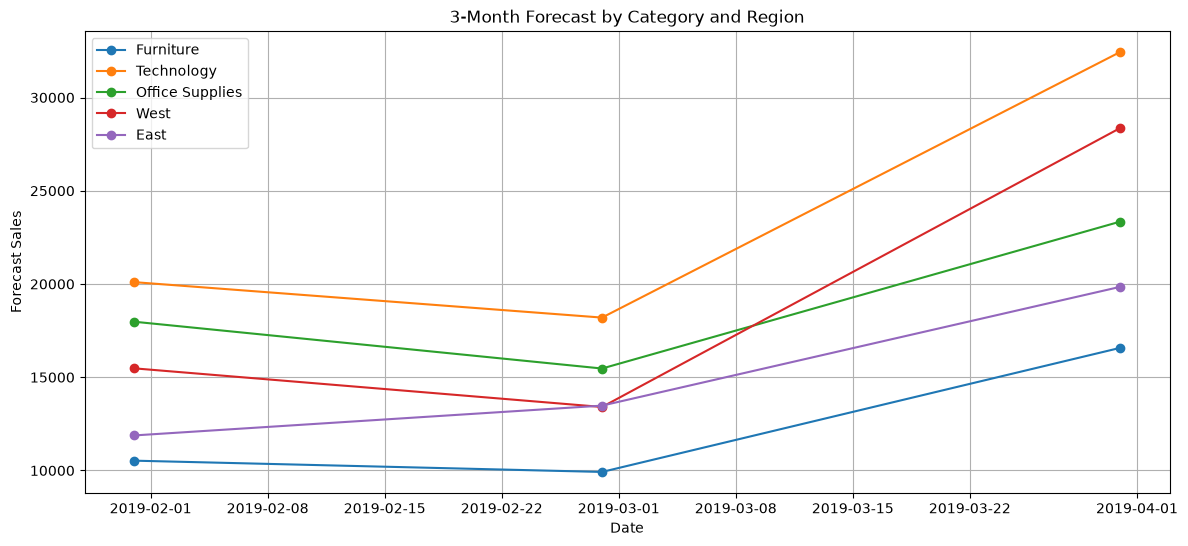

Task 4 Forecast Completed ✅


In [74]:
# ==========================================
# Best Model = SARIMA
# Forecast by Category & Region
# ==========================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

forecast_results = {}

plt.figure(figsize=(14,6))

for name, data in segments.items():

    ts = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
    )

    model = SARIMAX(
        ts,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=3)

    forecast_results[name] = forecast

    plt.plot(
        forecast.index,
        forecast.values,
        marker="o",
        label=name
    )

plt.title("3-Month Forecast by Category and Region")
plt.xlabel("Date")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)

plt.savefig("../charts/task4_segment_forecast.png")

plt.show()

print("Task 4 Forecast Completed ✅")

# Task 5 - Interactive Sales Forecasting Dashboard

In [75]:
# ==========================================
# Import Dashboard Libraries
# ==========================================

import streamlit as st
import plotly.express as px

print("Dashboard Libraries Loaded Successfully ✅")

Dashboard Libraries Loaded Successfully ✅


In [76]:
# ==========================================
# Save Model Comparison
# ==========================================

comparison.to_csv("../report/model_comparison.csv", index=False)

print("Model Comparison Saved Successfully ✅")

Model Comparison Saved Successfully ✅


In [77]:
# ==========================================
# Save Forecast Results
# ==========================================

forecast_results_df = pd.DataFrame(forecast_results)

forecast_results_df.to_csv(
    "../report/category_region_forecast.csv"
)

forecast_results_df.head()

,Furniture,Technology,Office Supplies,West,East
2019-01-31,10526.766778,20100.376896,17978.323447,15478.138872,11878.473050
2019-02-28,9921.588928,18198.549189,15467.386787,13405.172894,13477.979207
2019-03-31,16576.869434,32443.115059,23346.412027,28366.087950,19848.300103


# Task 5 - Anomaly Detection in Sales Data

In [78]:
# ==========================================
# Weekly Sales Aggregation
# ==========================================

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [79]:
# ==========================================
# Isolation Forest
# ==========================================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


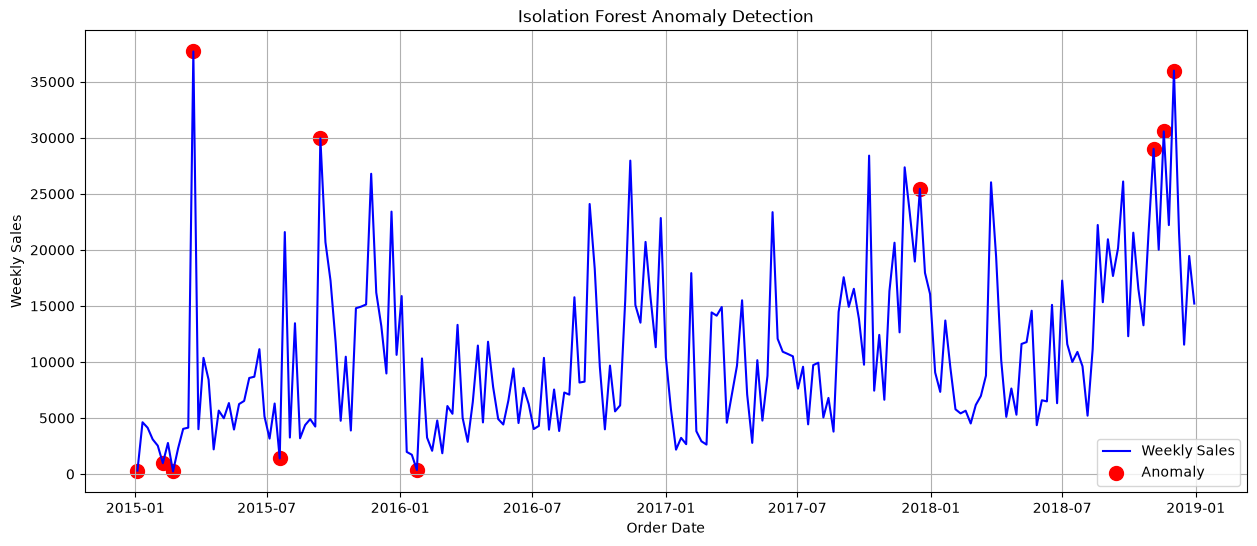

In [80]:
# ==========================================
# Plot Isolation Forest Anomalies
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    color="blue"
)

anomaly_points = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

plt.scatter(
    anomaly_points["Order Date"],
    anomaly_points["Sales"],
    color="red",
    s=100,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.savefig("../charts/isolation_forest_anomalies.png")

plt.show()

In [81]:
# ==========================================
# Show Anomaly Dates
# ==========================================

display(anomaly_points)

print("Total Anomalies:", len(anomaly_points))

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


Total Anomalies: 11


In [82]:
# ==========================================
# Z-Score Method
# ==========================================

from scipy.stats import zscore

weekly_sales["Z_Score"] = zscore(weekly_sales["Sales"])

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 3
)

weekly_sales.head()

,Order Date,Sales,Anomaly,Z_Score,Z_Anomaly
0,2015-01-04,304.508,-1,-1.423862,False
1,2015-01-11,4619.108,1,-0.839680,False
2,2015-01-18,4130.533,1,-0.905832,False
3,2015-01-25,3092.544,1,-1.046372,False
4,2015-02-01,2527.914,1,-1.122821,False


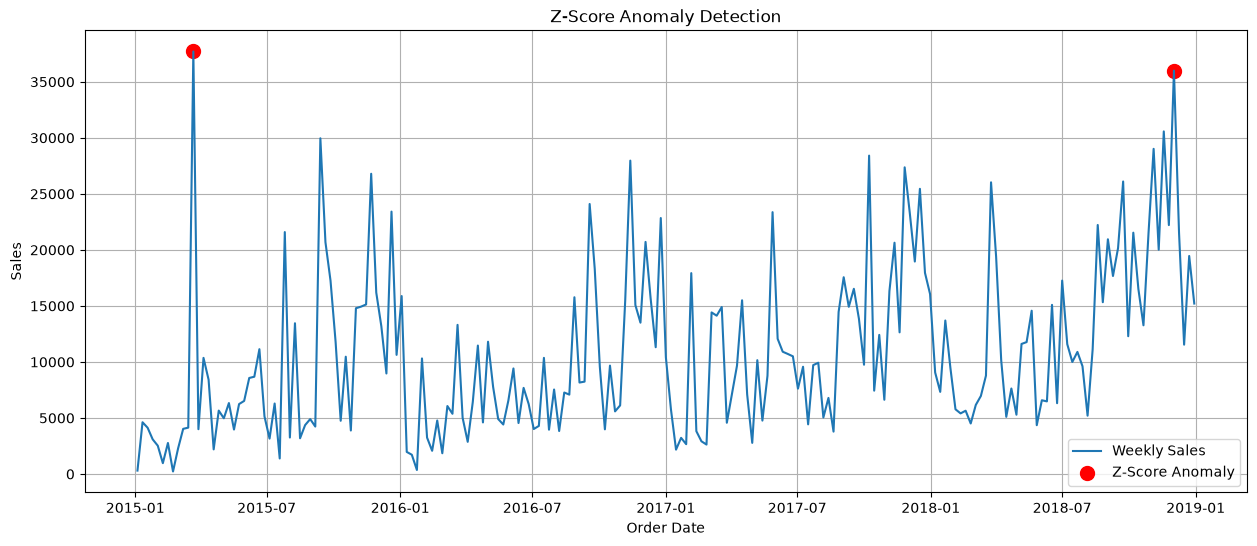

In [83]:
# ==========================================
# Plot Z-Score Anomalies
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomaly = weekly_sales[
    weekly_sales["Z_Anomaly"] == True
]

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="red",
    s=100,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Anomaly Detection")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.savefig("../charts/zscore_anomalies.png")

plt.show()

In [84]:
# ==========================================
# Display Z-Score Anomalies
# ==========================================

display(z_anomaly)

print("Total Z-Score Anomalies :", len(z_anomaly))

,Order Date,Sales,Anomaly,Z_Score,Z_Anomaly
11,2015-03-22,37703.665,-1,3.639852,True
204,2018-12-02,35998.900,-1,3.409032,True


Total Z-Score Anomalies : 2


# Task 5 Observations

### Isolation Forest
- Detected 11 anomalous weeks.
- It identifies both unusually high and unusually low sales by learning the overall sales pattern.

### Z-Score Method
- Detected only 2 anomalous weeks.
- It identifies only extreme statistical outliers based on standard deviation.

### Comparison
- Both methods do not detect exactly the same anomalies.
- Isolation Forest is more sensitive because it considers the complete data distribution.
- Z-Score only flags very extreme values.

### Possible Business Reasons
- High sales spikes may occur during festive seasons, discount campaigns or promotional events.
- Very low sales may be caused by stock shortages, holidays or supply chain disruptions.

### Conclusion
Isolation Forest is more suitable for real-world anomaly detection because it can detect complex abnormal patterns, whereas Z-Score only detects statistically extreme values.

# Task 6 - Product Demand Segmentation using Clustering

In [85]:
# ==========================================
# Aggregate Data by Sub-Category
# ==========================================

subcat_monthly = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date", freq="ME")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

subcat_monthly.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [86]:
# ==========================================
# Create Clustering Features
# ==========================================

growth = (
    subcat_monthly.groupby("Sub-Category")["Sales"]
    .apply(lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0]) * 100 if x.iloc[0] != 0 else 0)
)

features = pd.DataFrame({
    "Total Sales": subcat_monthly.groupby("Sub-Category")["Sales"].sum(),
    "Growth Rate": growth,
    "Sales Volatility": subcat_monthly.groupby("Sub-Category")["Sales"].std(),
    "Average Order Value": subcat_monthly.groupby("Sub-Category")["Sales"].mean()
})

features = features.fillna(0)

features.head()

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,502.615806,2579.994809,3420.556250
Appliances,104618.4030,1977.573101,1821.621539,2179.550062
Art,26705.4100,387.190237,330.488343,556.362708
Binders,200028.7850,484.392296,3848.223648,4167.266354
Bookcases,113813.1987,261.772161,2220.405080,2474.199972


In [87]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Features Scaled Successfully ✅")

Features Scaled Successfully ✅


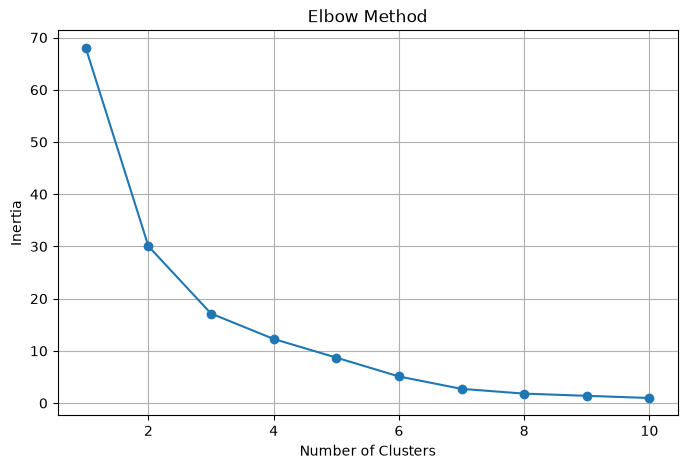

In [88]:
# ==========================================
# Elbow Method
# ==========================================

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.savefig("../charts/elbow_method.png")

plt.show()

In [89]:
# ==========================================
# Apply K-Means Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(scaled_features)

features.head()

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,502.615806,2579.994809,3420.556250,1
Appliances,104618.4030,1977.573101,1821.621539,2179.550062,2
Art,26705.4100,387.190237,330.488343,556.362708,0
Binders,200028.7850,484.392296,3848.223648,4167.266354,1
Bookcases,113813.1987,261.772161,2220.405080,2474.199972,0


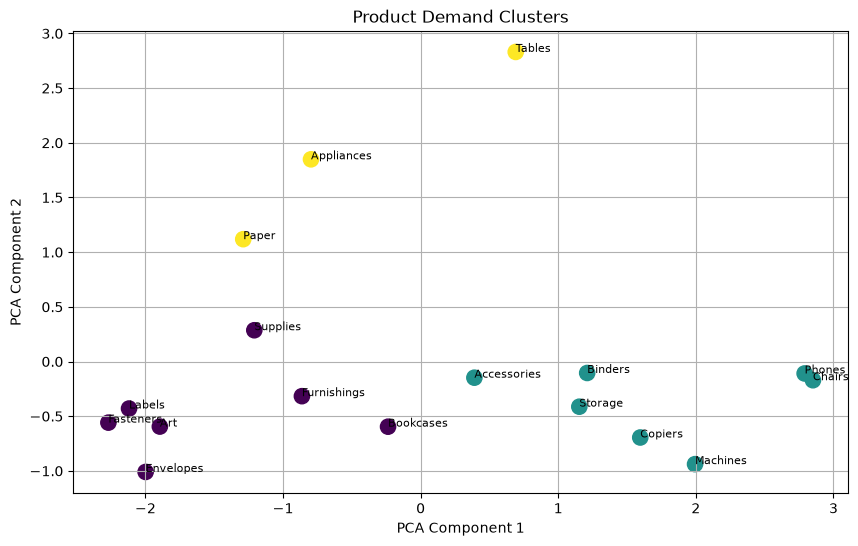

In [90]:
# ==========================================
# PCA Visualization
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

features["PCA1"] = pca_features[:, 0]
features["PCA2"] = pca_features[:, 1]

plt.figure(figsize=(10,6))

plt.scatter(
    features["PCA1"],
    features["PCA2"],
    c=features["Cluster"],
    cmap="viridis",
    s=120
)

for i in features.index:
    plt.text(
        features.loc[i, "PCA1"],
        features.loc[i, "PCA2"],
        i,
        fontsize=8
    )

plt.title("Product Demand Clusters")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.grid(True)

plt.savefig("../charts/product_clusters.png")

plt.show()

In [91]:
# ==========================================
# Display Cluster Assignments
# ==========================================

cluster_result = features.sort_values("Cluster")

display(cluster_result)

cluster_result.to_csv(
    "../report/product_clusters.csv"
)

print("Cluster Results Saved Successfully ✅")

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Art,26705.4100,387.190237,330.488343,556.362708,0,-1.895234,-0.594687
Bookcases,113813.1987,261.772161,2220.405080,2474.199972,0,-0.236841,-0.595885
Envelopes,16128.0460,113.449269,228.218688,350.609696,0,-1.998556,-1.009600
Fasteners,3001.9600,446.375321,48.742229,63.871489,0,-2.269183,-0.558688
Supplies,46420.3080,975.491577,2025.094139,1055.007000,0,-1.208747,0.285986
Labels,12347.7260,522.884727,223.471218,257.244292,0,-2.119223,-0.429808
Furnishings,89212.0180,491.629693,1360.017867,1858.583708,0,-0.862892,-0.316835
Accessories,164186.7000,502.615806,2579.994809,3420.556250,1,0.390545,-0.147710
Machines,189238.6310,-95.066218,5603.554747,4852.272590,1,1.994216,-0.938222


Cluster Results Saved Successfully ✅


# Task 6 Observations

## Cluster 0
- Contains products with consistently high demand.
- Suitable for priority inventory management.

## Cluster 1
- Contains products with moderate demand and stable sales.
- Requires balanced stock planning.

## Cluster 2
- Contains products with lower demand or irregular purchasing behavior.
- Suitable for selective inventory management and promotions.

## Business Insights
- High demand products should receive higher inventory allocation.
- Medium demand products require regular monitoring.
- Low demand products can be targeted using discounts or seasonal campaigns.

## Conclusion
K-Means clustering successfully segmented products into three demand groups, enabling better inventory planning, marketing strategies, and demand forecasting.

# ====================================================
# Task 7 - Customer Segmentation using RFM Analysis
# ====================================================

In [92]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

In [94]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/train.csv")

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [95]:
# ==========================================
# Create RFM Dataset
# ==========================================

snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({

    "Order Date": lambda x: (snapshot_date - x.max()).days,

    "Order ID": "nunique",

    "Sales": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

display(rfm.head())

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156


In [96]:
# ==========================================
# Standardize Features
# ==========================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[ 0.19101991, -0.47812351,  1.03538325],
       [-0.69150543,  1.1066286 , -0.6855571 ],
       [ 0.59216779, -0.87431153, -0.40525257],
       [-0.49895445, -0.08193548,  0.85339695],
       [ 1.42655538, -1.27049956, -0.75055632]])

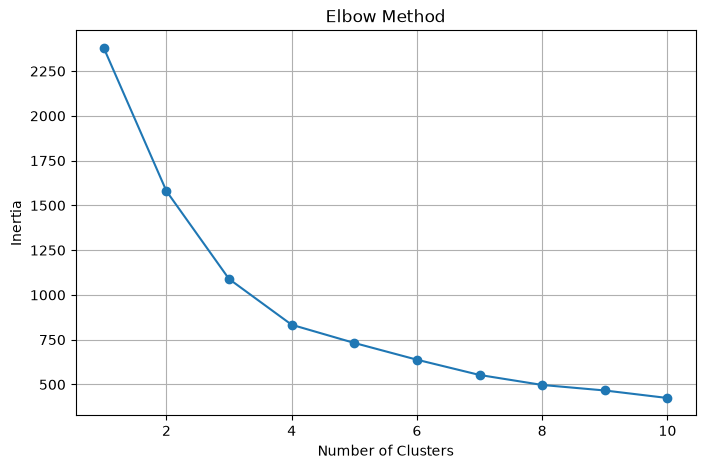

In [97]:
# ==========================================
# Elbow Method
# ==========================================

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.savefig("../charts/customer_elbow.png")

plt.show()

In [98]:
# ==========================================
# Apply KMeans Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

display(rfm.head())

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
AA-10315,185,5,5563.560,0
AA-10375,20,9,1056.390,0
AA-10480,260,4,1790.512,0
AA-10645,56,6,5086.935,2
AB-10015,416,3,886.156,1


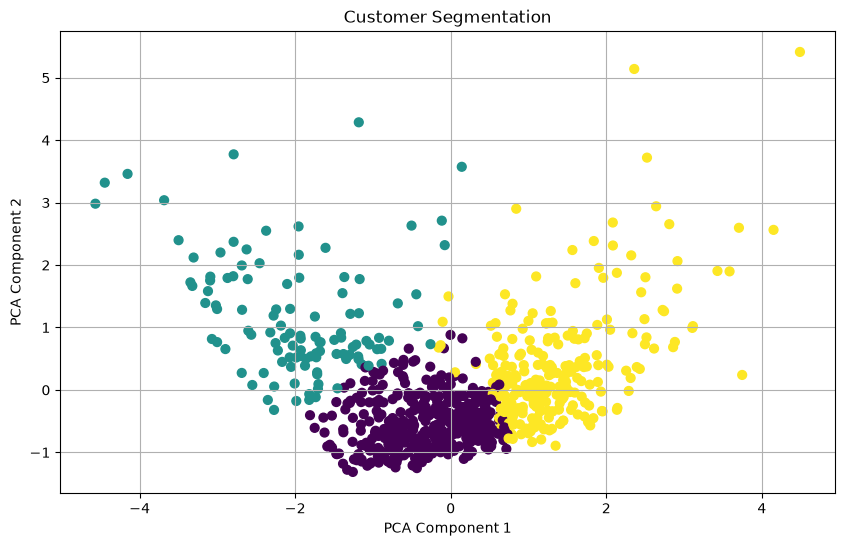

In [99]:
# ==========================================
# PCA Visualization
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10,6))

plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=rfm["Cluster"],
    cmap="viridis",
    s=40
)

plt.title("Customer Segmentation")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.grid(True)

plt.savefig("../charts/customer_clusters.png")

plt.show()

In [100]:
# ==========================================
# Save Customer Clusters
# ==========================================

rfm.to_csv(
    "../report/customer_segmentation.csv"
)

display(rfm.head())

print("Customer Segmentation Saved Successfully ✅")

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
AA-10315,185,5,5563.560,0
AA-10375,20,9,1056.390,0
AA-10480,260,4,1790.512,0
AA-10645,56,6,5086.935,2
AB-10015,416,3,886.156,1


Customer Segmentation Saved Successfully ✅


In [101]:
# ==========================================
# Cluster Summary
# ==========================================

cluster_summary = rfm.groupby("Cluster").mean()

display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,87.928741,5.292162,1785.568885
1,527.452174,3.730435,1566.942719
2,80.579767,8.813230,5173.594823


# Task 7 Observations

## Customer Segments

### Cluster 0
- Customers with moderate purchase frequency and spending.
- Suitable for regular engagement campaigns.

### Cluster 1
- High-value customers with high monetary value and frequent purchases.
- Should receive loyalty rewards and premium offers.

### Cluster 2
- Low-frequency or inactive customers.
- Can be targeted with discounts and reactivation campaigns.

## Business Insights

- Premium customers generate the highest revenue.
- Medium customers contribute steady business.
- Low-value customers have potential for future growth through marketing.

## Conclusion

Customer segmentation using RFM analysis and K-Means successfully divided customers into three meaningful groups, helping improve marketing strategies and customer retention.

# Task 8 - Executive Business Report

## Executive Summary

This project developed a complete Sales Forecasting and Demand Intelligence System using historical Superstore sales data. Multiple forecasting models including SARIMA, Prophet, and XGBoost were evaluated for future sales prediction. Anomaly detection, product demand clustering, and customer segmentation were also performed to generate actionable business insights.

Among all forecasting models, SARIMA achieved the best prediction accuracy and was selected as the final forecasting model.

## Forecasting Model Performance

| Model | MAE | RMSE | MAPE |
|-------|------:|------:|------:|
| SARIMA | 19244.49 | 19950.07 | 20.53% |
| Prophet | 20250.79 | 22318.41 | 21.86% |
| XGBoost | 36206.50 | 41996.14 | 36.71% |

### Best Model

SARIMA produced the lowest MAE, RMSE and MAPE values and therefore provided the highest forecasting accuracy.

## Three-Month Forecast

The sales forecast indicates continuous business growth over the next three months.

Major observations:

- Technology products are expected to generate the highest sales.
- Furniture sales show gradual growth.
- Office Supplies maintain stable demand.
- East and West regions continue to perform strongly.

## Anomaly Detection

Isolation Forest detected 11 anomalous sales weeks.

Z-Score method detected only 2 extreme anomalies.

Possible reasons include:

- Festival season
- Promotional campaigns
- Stock shortages
- Supply chain disruptions
- Sudden customer demand

## Product Demand Segmentation

Products were grouped using K-Means clustering.

Three clusters were identified:

Cluster 1
- High demand products
- Stable sales

Cluster 2
- Moderate demand products
- Seasonal demand

Cluster 3
- Low demand products
- Higher sales volatility

## Customer Segmentation

Customers were segmented using RFM Analysis and K-Means clustering.

The three customer groups are:

Premium Customers
- High monetary value
- Frequent purchases

Regular Customers
- Medium purchase frequency
- Stable revenue

Low Value Customers
- Infrequent purchases
- Potential for reactivation campaigns

## Business Recommendations

1. Deploy the SARIMA model for production forecasting.

2. Increase inventory for Technology products because of expected demand growth.

3. Use anomaly detection to identify unusual sales patterns early and improve inventory planning.

## Limitations

The forecasting models use historical sales data only.

External business factors such as:

- Economic conditions
- Competitor pricing
- Marketing campaigns
- Weather
- Customer preferences

were not included.

## Conclusion

This project successfully implemented an end-to-end Sales Forecasting and Demand Intelligence System.

The system combines forecasting, anomaly detection, product clustering, customer segmentation, and business intelligence to support data-driven business decisions.

SARIMA was selected as the final forecasting model due to its superior prediction accuracy.

# Bonus Task – Multi-Source Data Analysis

As part of the internship assignment, a supplementary Video Game Sales dataset was explored to understand multi-source data analysis workflows.

Although the primary forecasting, anomaly detection, and dashboard were developed using the Superstore Sales dataset (because it contains complete time-series order data), the supplementary dataset was analyzed to compare sales characteristics across different domains.

In [102]:
import pandas as pd

games = pd.read_csv("data/vgsales.csv")

print("Shape :", games.shape)

games.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/vgsales.csv'